**Libraries and Dataset Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve

# Load dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

**Dataset Description and EDA**

Total Data Points: 5110
Number of Features: 11
Feature Types:
 id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


/tmp/ipykernel_25727/3413718036.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


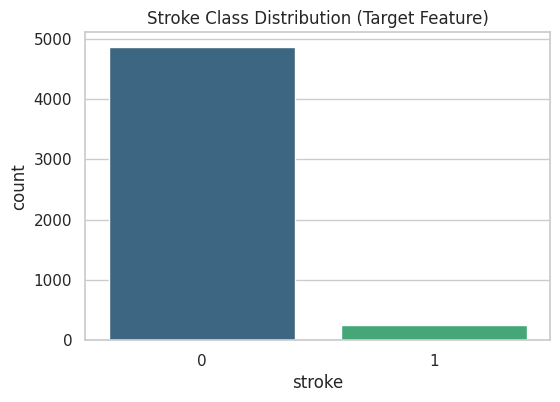

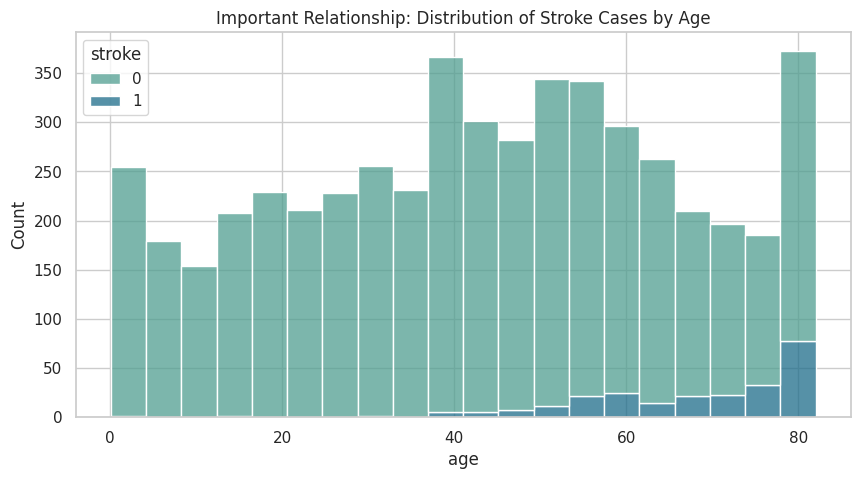

/tmp/ipykernel_25727/3413718036.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="heart_disease", y="stroke", palette="magma")


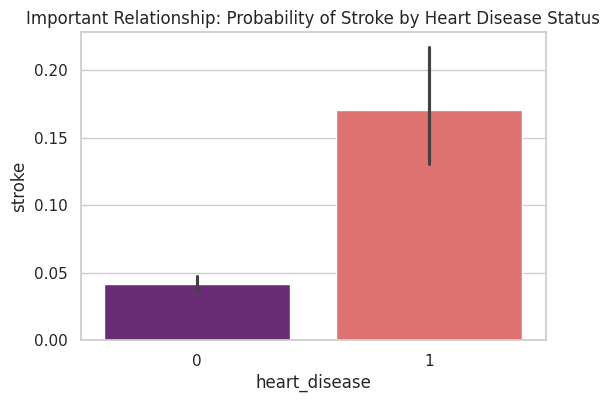

In [ ]:
print(f"Total Data Points: {df.shape[0]}")
print(f"Number of Features: {df.shape[1] - 1}")
print("Feature Types:\n", df.dtypes)

# Imbalanced Dataset Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('Stroke Class Distribution (Target Feature)')
plt.show()

# EDA: Important Relationships
# Relationship 1: Age vs Stroke
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="age", hue="stroke", multiple="stack", palette="crest")
plt.title("Important Relationship: Distribution of Stroke Cases by Age")
plt.show()

# Relationship 2: Heart Disease vs Stroke
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="heart_disease", y="stroke", palette="magma")
plt.title("Important Relationship: Probability of Stroke by Heart Disease Status")
plt.show()

**Pre-processing**

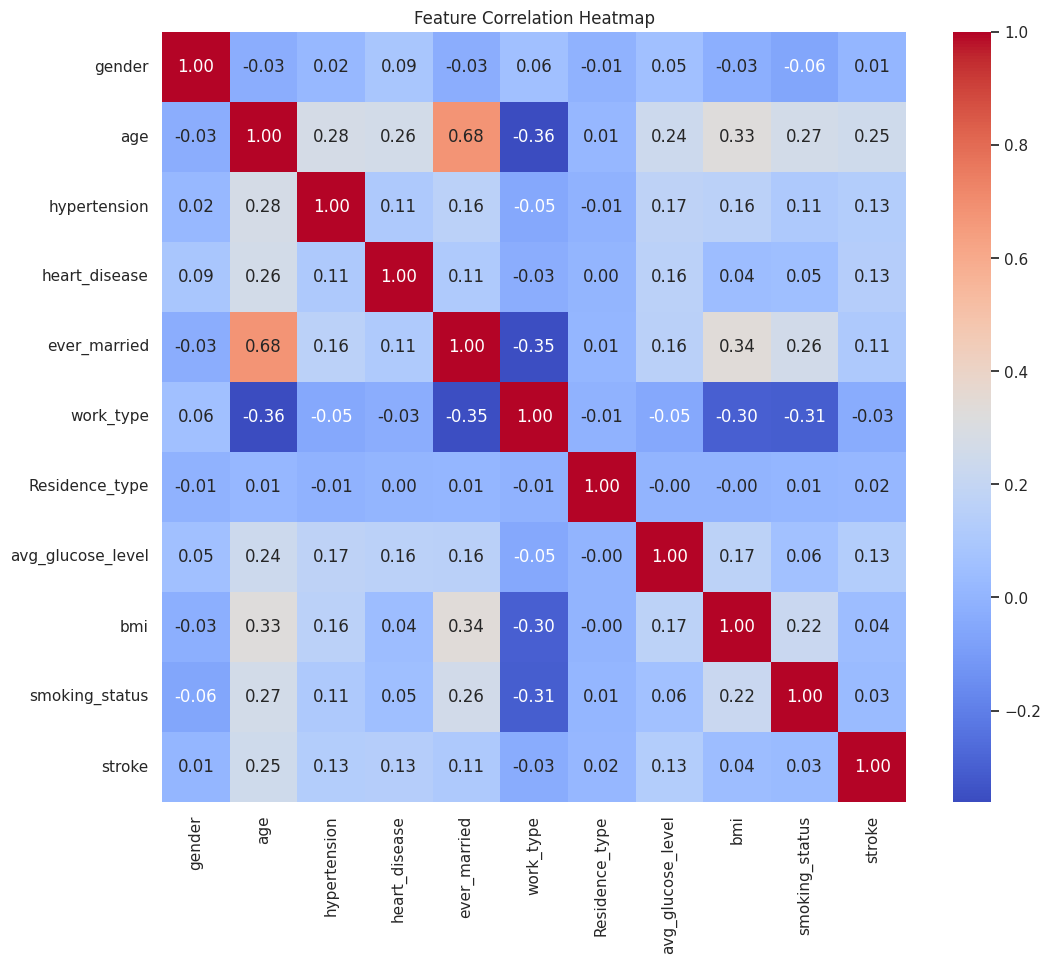

In [ ]:
# Problem 1: Other Gender (Minor Data Cleaning)
df = df[df['gender'] != 'Other']

# Problem 2: Missing Values in 'bmi' (Mean Imputation)
imputer = SimpleImputer(strategy='mean')
df['bmi'] = imputer.fit_transform(df[['bmi']])

# Problem 3: Encoding Categorical Variables (Label Encoding)
le = LabelEncoder()
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Correlation Heatmap (apply heatmap using seaborn)
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop('id', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

**Dataset Splitting & Handling Imbalance**

In [ ]:
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Random/Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Solution for Imbalance: Manual Random Oversampling on Training Data
train_data = pd.concat([X_train, y_train], axis=1)
no_stroke = train_data[train_data.stroke == 0]
stroke = train_data[train_data.stroke == 1]
stroke_upsampled = stroke.sample(n=len(no_stroke), replace=True, random_state=42)
upsampled_train = pd.concat([no_stroke, stroke_upsampled])

X_train_res = upsampled_train.drop('stroke', axis=1)
y_train_res = upsampled_train['stroke']

# Feature Scaling (Standard Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

**Model Training And Testing**


K-means Cluster Stroke Rate:
Cluster
0    0.030469
1    0.592518
Name: Stroke, dtype: float64


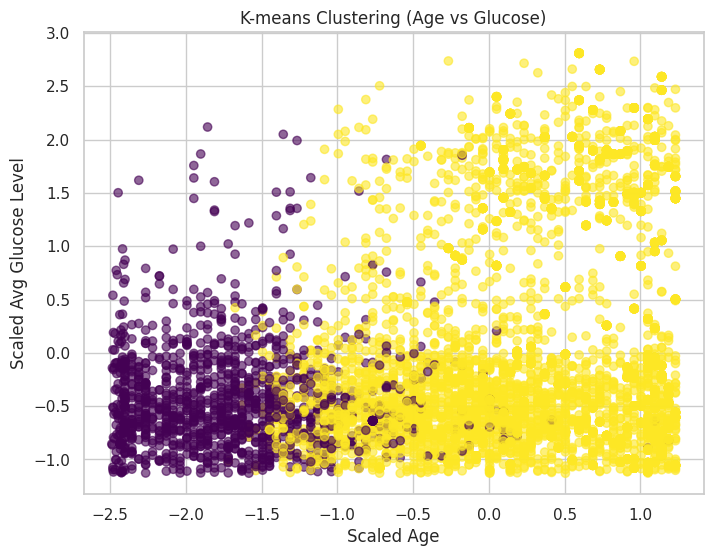

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Probabilities": y_prob
    }

# Unsupervised Learning (K-means) ---
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

# Analysis for Conclusion
cluster_analysis = pd.DataFrame({'Cluster': clusters, 'Stroke': y_train_res}).groupby('Cluster')['Stroke'].mean()
print("\nK-means Cluster Stroke Rate:")
print(cluster_analysis)

# Plotting Age (index 1) vs Average Glucose Level (index 8) from scaled features
plt.figure(figsize=(8, 6))
plt.scatter(X_train_final[:, 1], X_train_final[:, 7], c=clusters, cmap='viridis', alpha=0.6)
plt.title('K-means Clustering (Age vs Glucose)')
plt.xlabel('Scaled Age')
plt.ylabel('Scaled Avg Glucose Level')
plt.show()

**Comparison Analysis**

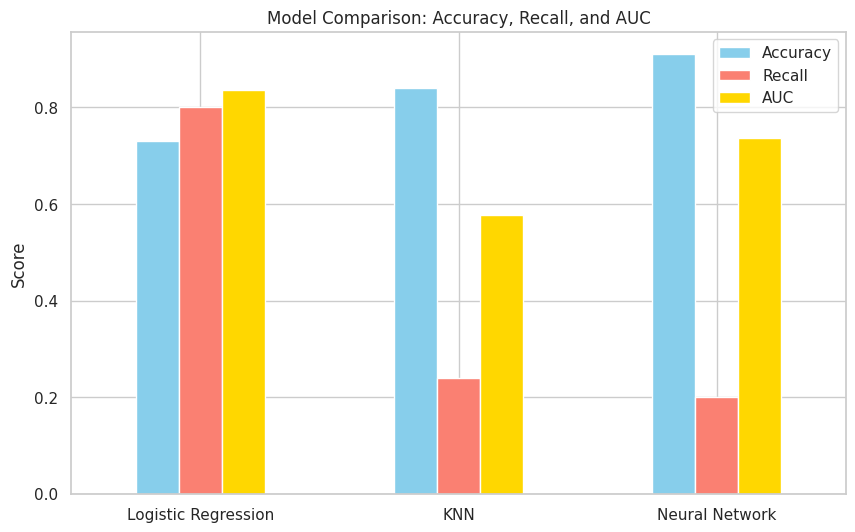

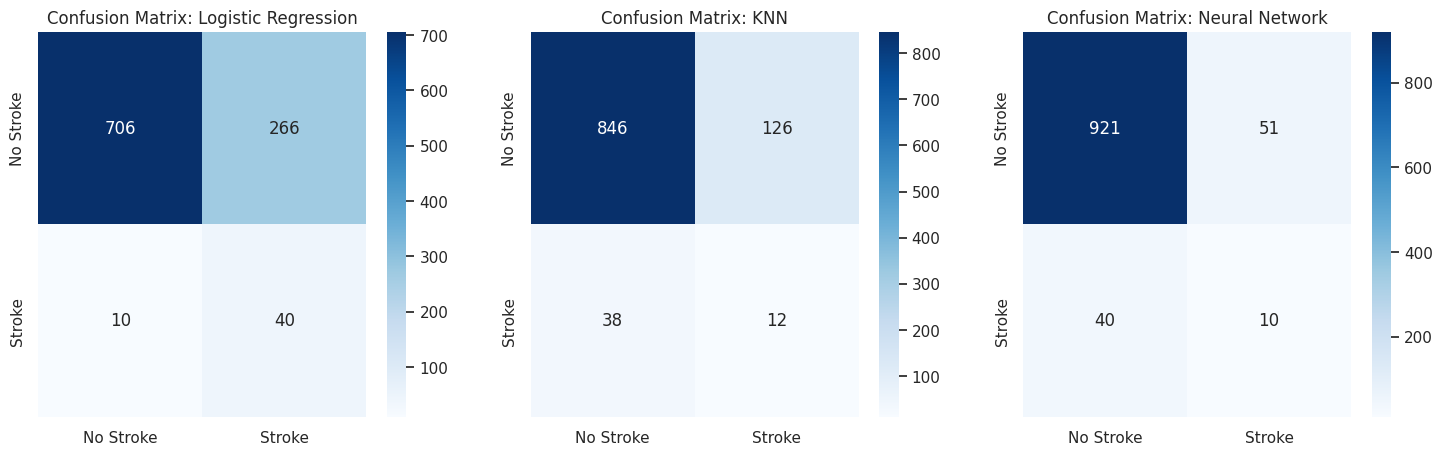

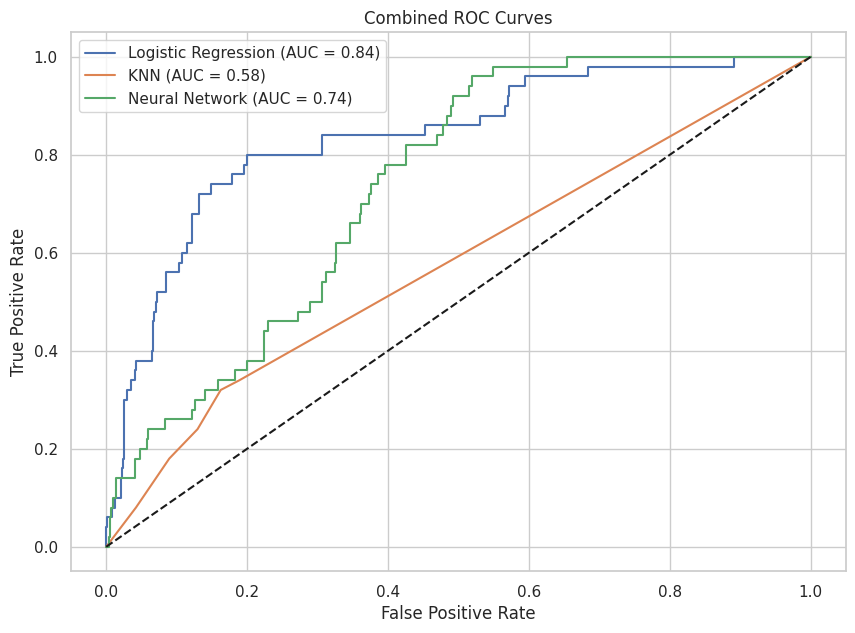


Model Performance Summary:
                     Accuracy Precision Recall       AUC
Logistic Regression  0.729941  0.130719    0.8  0.835988
KNN                   0.83953  0.086957   0.24  0.577479
Neural Network       0.910959  0.163934    0.2  0.737531


In [ ]:
# 1. Bar Chart: Prediction Accuracy, Recall, and AUC
metrics_df = pd.DataFrame(results).T[['Accuracy', 'Recall', 'AUC']]
metrics_df.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon', 'gold'])
plt.title("Model Comparison: Accuracy, Recall, and AUC")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# 2. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, res) in enumerate(results.items()):
    sns.heatmap(res["Confusion Matrix"], annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
    axes[i].set_title(f'Confusion Matrix: {name}')
plt.show()

# 3. AUC score and ROC curve for each model
plt.figure(figsize=(10, 7))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["Probabilities"])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {res["AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves')
plt.legend()
plt.show()

# Summary Table
print("\nModel Performance Summary:")
print(pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'AUC']])